In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
L = 16
chi_list = [64, 128, 256]
alpha = 0.0

In [3]:
results = {}
for chi in chi_list:
    filename = Path(f"results/n_profile_vs_t_L{L}_chi{chi}_alpha{alpha}.csv")
    df = pd.read_csv(filename, comment="#")
    required = ["time"] + [f'n_{j+1}' for j in range(L)]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns in {filename}: {missing}")
    times     = df['time'].values
    entropy   = df['entropy'].values
    trunc_err = df['truncation_error'].values
    energy    = df['energy'].values
    n_matrix  = np.column_stack([df[f'n_{j+1}'].values for j in range(L)])
    assert n_matrix.shape == (len(times), L), (
        f"n_matrix shape mismatch: {n_matrix.shape}"
    )
    results[chi]            = {}
    results[chi]['times']     = times
    results[chi]['entropy']   = entropy
    results[chi]['trunc_err'] = trunc_err
    results[chi]['energy']    = energy
    results[chi]['n_matrix']  = n_matrix


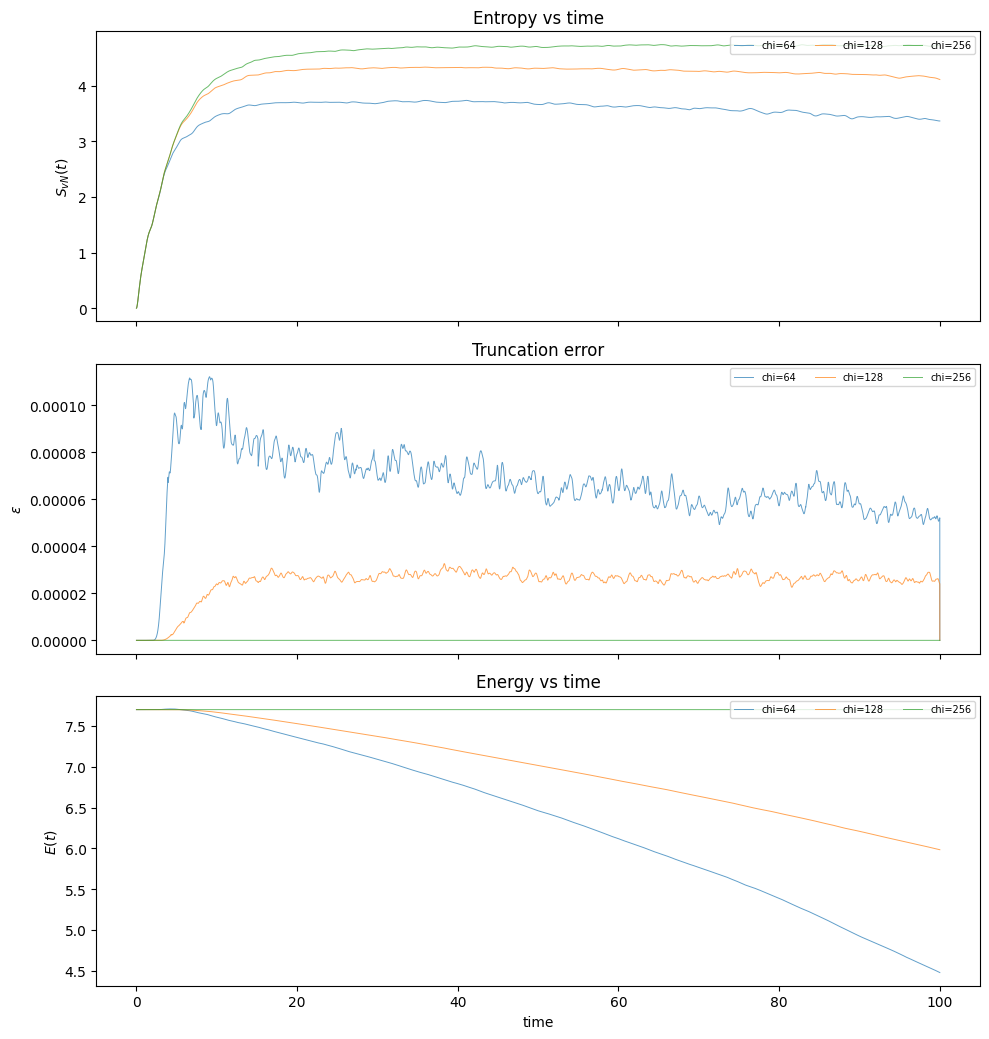

In [4]:
n_rows = 3
subplot_h, subplot_w = 3.5, 10
fig, axes = plt.subplots(n_rows, 1, figsize=(subplot_w, subplot_h * n_rows), sharex=True)

for chi in chi_list:
    ax_entr =   axes[0]
    ax_truc =   axes[1]
    ax_ener =   axes[2]

    times   =   results[chi]['times']
    entropy =   results[chi]['entropy']
    trunc_err   =   results[chi]['trunc_err']
    energy  =   results[chi]['energy']

    ax_entr.plot(times, entropy, lw=0.7, alpha=0.7,label=f'chi={chi}')
    ax_truc.plot(times, trunc_err, lw=0.7, alpha=0.7,label=f'chi={chi}')
    ax_ener.plot(times, energy, lw=0.7, alpha=0.7,label=f'chi={chi}')

ax_entr.set_title(f'Entropy vs time')
ax_entr.set_ylabel(r'$S_{vN}(t)$')
ax_entr.legend(ncol=4, fontsize=7, loc='upper right')

ax_truc.set_title('Truncation error')
ax_truc.set_ylabel(r'$\epsilon$')
ax_truc.legend(ncol=4, fontsize=7, loc='upper right')

ax_ener.set_title(f"Energy vs time")
ax_ener.set_ylabel(r'$E(t)$')
ax_ener.set_xlabel('time')
ax_ener.legend(ncol=4, fontsize=7, loc='upper right')


plt.tight_layout()
plt.show()

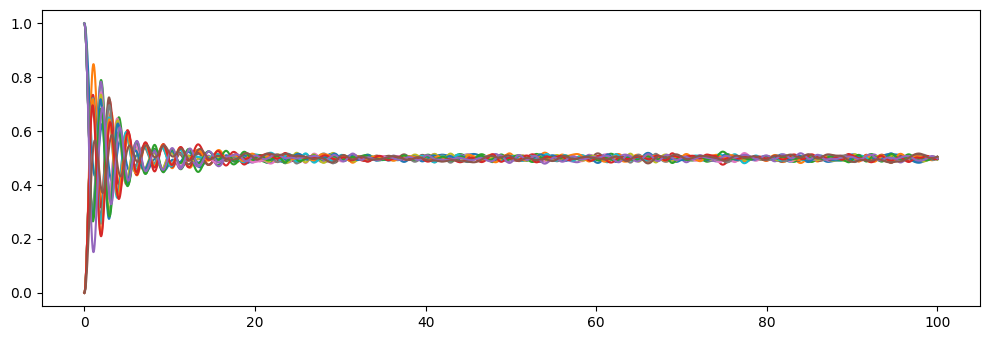

In [5]:
plt.figure(figsize=(10,3.5))
for j in range(L):
    plt.plot(times, n_matrix[:,j], label=f'n_{j}(t)')
# plt.xscale("log")
plt.tight_layout()
plt.show()

In [8]:
step = int(40/0.005)

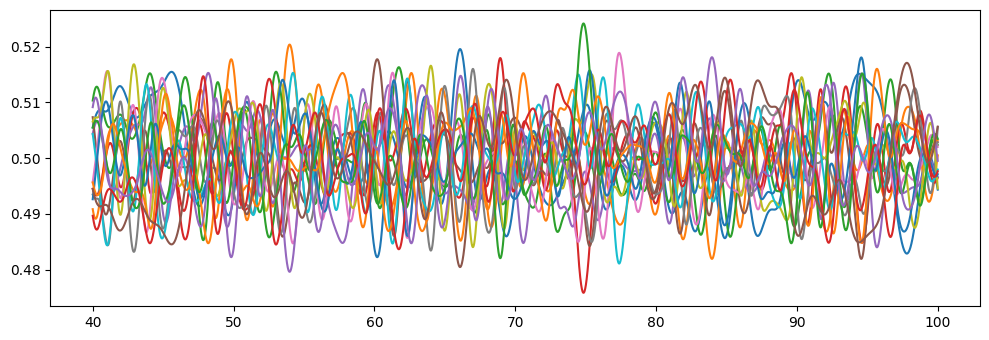

In [9]:
plt.figure(figsize=(10,3.5))
for j in range(L):
    plt.plot(times[step:], n_matrix[step:,j], label=f'n_{j}(t)')
# plt.xscale("log")
plt.tight_layout()
plt.show()

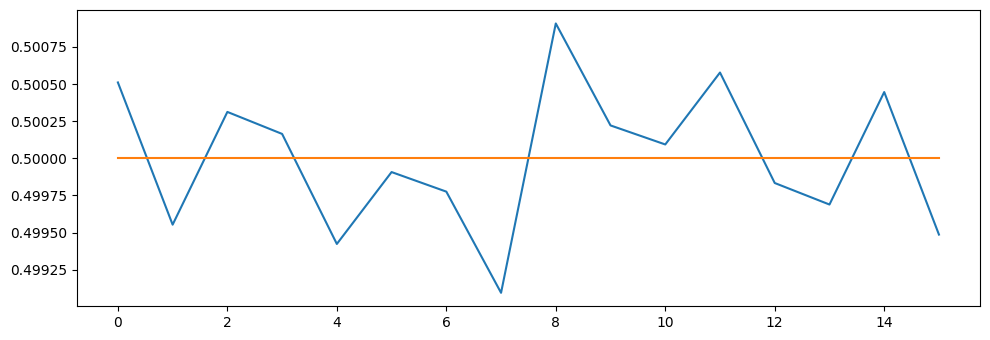

In [16]:
plt.figure(figsize=(10,3.5))
plt.plot([j for j in range(L)], [n_matrix[step:,j].mean(axis=0) for j in range(L)], label=f'n_{j}(t)')
plt.plot([j for j in range(L)], [np.sum(n_matrix[0])/L for j in range(L)])
plt.tight_layout()
plt.show()